In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library impor    # qct = transpile(qc,basis_gates = ['cx','id', 'x', 'rx', 'rz'])
    # Noise_sim = AerSimulator.from_backend(backend)t UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()

# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 4

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

b = 0.25*np.array([0,1,1,1,1,1,1,1,1,1,1,1,1,2,0,0])
nb_qubits = 4

In [3]:
np.linalg.det(m)



15.999999999999984

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([1.52655666e-16+1.80411242e-16j, 2.50000000e-01+2.11636264e-15j,
       2.50000000e-01+1.85962357e-15j, 2.50000000e-01+1.74860126e-15j,
       2.50000000e-01-1.05471187e-15j, 2.50000000e-01-1.30451205e-15j,
       2.50000000e-01-1.49880108e-15j, 2.50000000e-01-1.74860126e-15j,
       2.50000000e-01-2.19269047e-15j, 2.50000000e-01-1.87350135e-15j,
       2.50000000e-01-1.66533454e-15j, 2.50000000e-01-1.41553436e-15j,
       2.50000000e-01+1.41553436e-15j, 5.00000000e-01+2.92821323e-15j,
       0.00000000e+00+8.32667268e-17j, 0.00000000e+00+1.84889275e-32j])

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(i,j,k,l):
        return np.kron(i,np.kron(j,np.kron(k,l)))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,z,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([ 1.05409197e+01-9.76789505e-30j,  8.43423780e+00-4.80217939e-30j,
        7.03186296e+00+1.39251751e-29j,  6.13672278e+00-3.58158225e-29j,
        4.82453150e+00+1.81470163e-29j,  4.28987417e+00+2.92451276e-29j,
        2.63515514e+00+1.80148141e-31j,  1.78741871e+00-8.99093850e-30j,
        1.34598333e+00-4.40491932e-30j,  8.02047496e-01+3.30873270e-29j,
        5.85228713e-01+7.08078820e-30j,  3.49301362e-01+3.06709348e-29j,
        1.74677943e-01+3.95042419e-30j,  2.91479977e-02+1.23059217e-29j,
        6.39497219e-03+6.75197540e-30j, -4.68988464e-16-2.52434029e-31j])

In [7]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
C_u5gate=u5gate.control()
C_u6gate=u6gate.control()
C_u7gate=u7gate.control()
C_u8gate=u8gate.control()
    

[0.98600511 0.39693224 0.72089462 0.36135681 0.39371065 0.64181
 0.54087274 0.15596923 0.42179262 0.51678456 0.22916061 0.66736852
 0.06578829 0.18780831 0.90302615 0.61387919 0.07571959 0.78783502
 0.80335611 0.8656569  0.36694413 0.56447486 0.49885888 0.85887889
 0.21442787 0.8140991  0.17225246 0.09192131 0.48053858 0.1978216
 0.83790844 0.34412944 0.3005543  0.33562501 0.44945517 0.06735328]


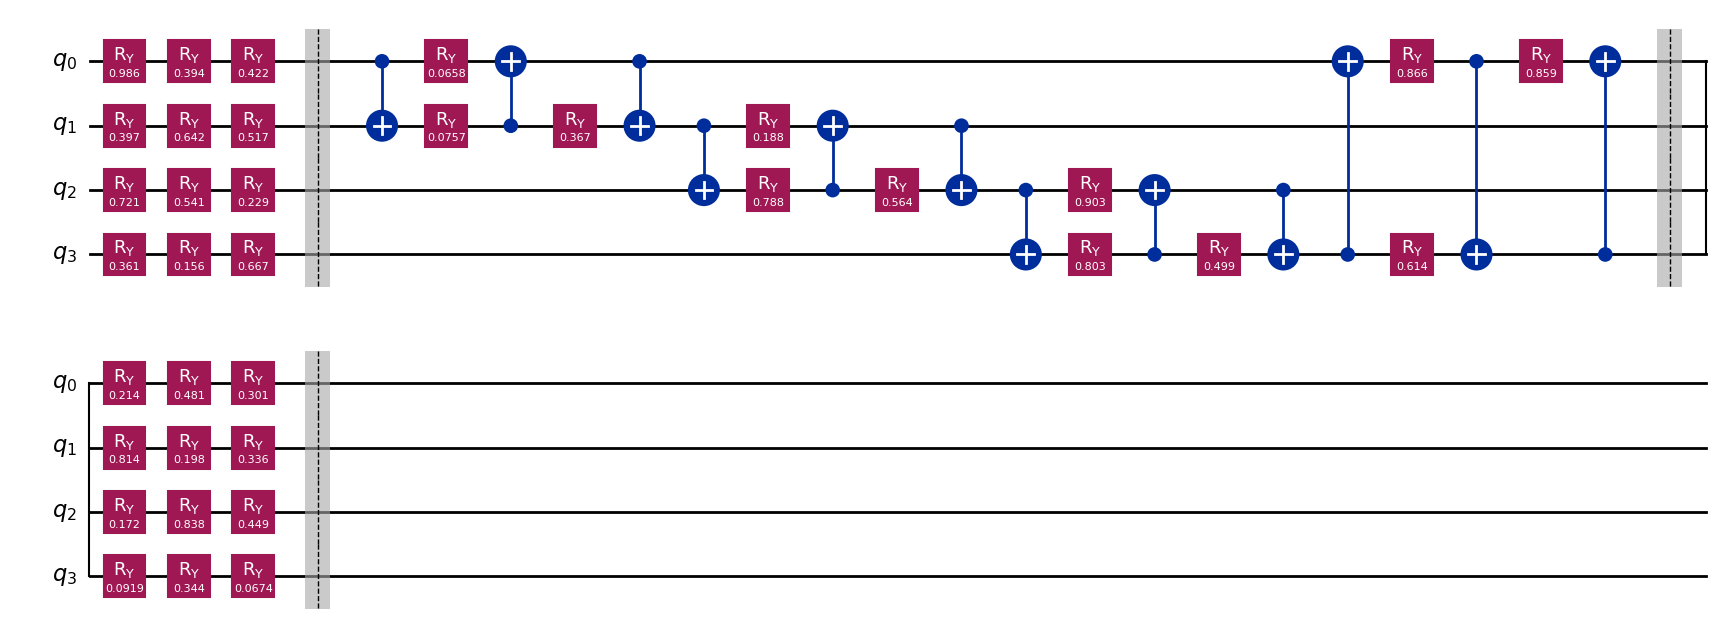

In [8]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc

nb_qubits=4
depth=1
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
# Parameters = np.array([random.random() for _ in range(0, nb_params)])

Parameters = np.array([0.98600511, 0.39693224, 0.72089462, 0.36135681, 0.39371065, 0.64181,
 0.54087274, 0.15596923, 0.42179262, 0.51678456, 0.22916061, 0.66736852,
 0.06578829, 0.18780831, 0.90302615, 0.61387919, 0.07571959, 0.78783502,
 0.80335611, 0.8656569,  0.36694413, 0.56447486, 0.49885888, 0.85887889,
 0.21442787, 0.8140991,  0.17225246, 0.09192131, 0.48053858, 0.1978216,
 0.83790844, 0.34412944, 0.3005543,  0.33562501, 0.44945517, 0.06735328])
print(Parameters)
ansatz(Parameters).draw("mpl")

In [9]:

# def ansatz(Parameters):
#     qc = QuantumCircuit(nb_qubits)
#     for d in range(depth):
#         parameters = Parameters[d*36:(d+1)*36]
#         qc.rz(parameters[0],0)
#         qc.ry(parameters[1],0)
#         qc.rz(parameters[2],0)
    
#         qc.rz(parameters[3],1)
#         qc.ry(parameters[4],1)
#         qc.rz(parameters[5],1)
    
#         qc.rz(parameters[6],2)
#         qc.ry(parameters[7],2)
#         qc.rz(parameters[8],2)

#         qc.rz(parameters[9],3)
#         qc.ry(parameters[10],3)
#         qc.rz(parameters[11],3)
    
#         qc.cx(0,1)
#         qc.cx(2,0)
#         qc.cx(1,3)
#         qc.cx(3,2)
    
#         qc.rz(parameters[12],0)
#         qc.ry(parameters[13],0)
#         qc.rz(parameters[14],0)
    
#         qc.rz(parameters[15],1)
#         qc.ry(parameters[16],1)
#         qc.rz(parameters[17],1)

#         qc.rz(parameters[18],2)
#         qc.ry(parameters[19],2)
#         qc.rz(parameters[20],2)

#         qc.rz(parameters[21],3)
#         qc.ry(parameters[22],3)
#         qc.rz(parameters[23],3)
    
#         qc.cx(1,0)
#         qc.cx(1,2)
#         qc.cx(0,3)
#         qc.cx(3,1)
#         if d == depth - 1:
#             qc.rz(Parameters[(d+1)*36-12],0)
#             qc.ry(Parameters[(d+1)*36-11],0)
#             qc.rz(Parameters[(d+1)*36-10],0)
        
#             qc.rz(Parameters[(d+1)*36-9],1)
#             qc.ry(parameters[(d+1)*36-8],1)
#             qc.rz(Parameters[(d+1)*36-7],1)
            
#             qc.rz(Parameters[(d+1)*36-6],2)
#             qc.ry(Parameters[(d+1)*36-5],2)
#             qc.rz(Parameters[(d+1)*36-4],2)

#             qc.rz(Parameters[(d+1)*36-3],3)
#             qc.ry(Parameters[(d+1)*36-2],3)
#             qc.rz(Parameters[(d+1)*36-1],3)
#     return qc
# depth = 1
# Parameters = np.array([random.random() for _ in range(0, 72)])


# print(Parameters)
# ansatz(Parameters).draw("mpl")


In [10]:

def circ(Parameters):
    x=QuantumRegister(12)
    c=ClassicalRegister(8)
    circuit = QuantumCircuit(x,c)

    circuit=circuit.compose(ansatz(Parameters),x[8:12])
    circuit.h(x[0:8]) 
    circuit.append(C_u1gate, [x[0],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u2gate, [x[1],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u3gate, [x[2],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u4gate, [x[3],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u5gate, [x[4],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u6gate, [x[5],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u7gate, [x[6],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u8gate, [x[7],x[8],x[9],x[10],x[11]]) 
    circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True, 
                   inverse=True, insert_barriers=False, name='qft')
    circuit.measure(x[0:8],c)       
    return circuit

/tmp/ipykernel_2116395/2620722776.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True,


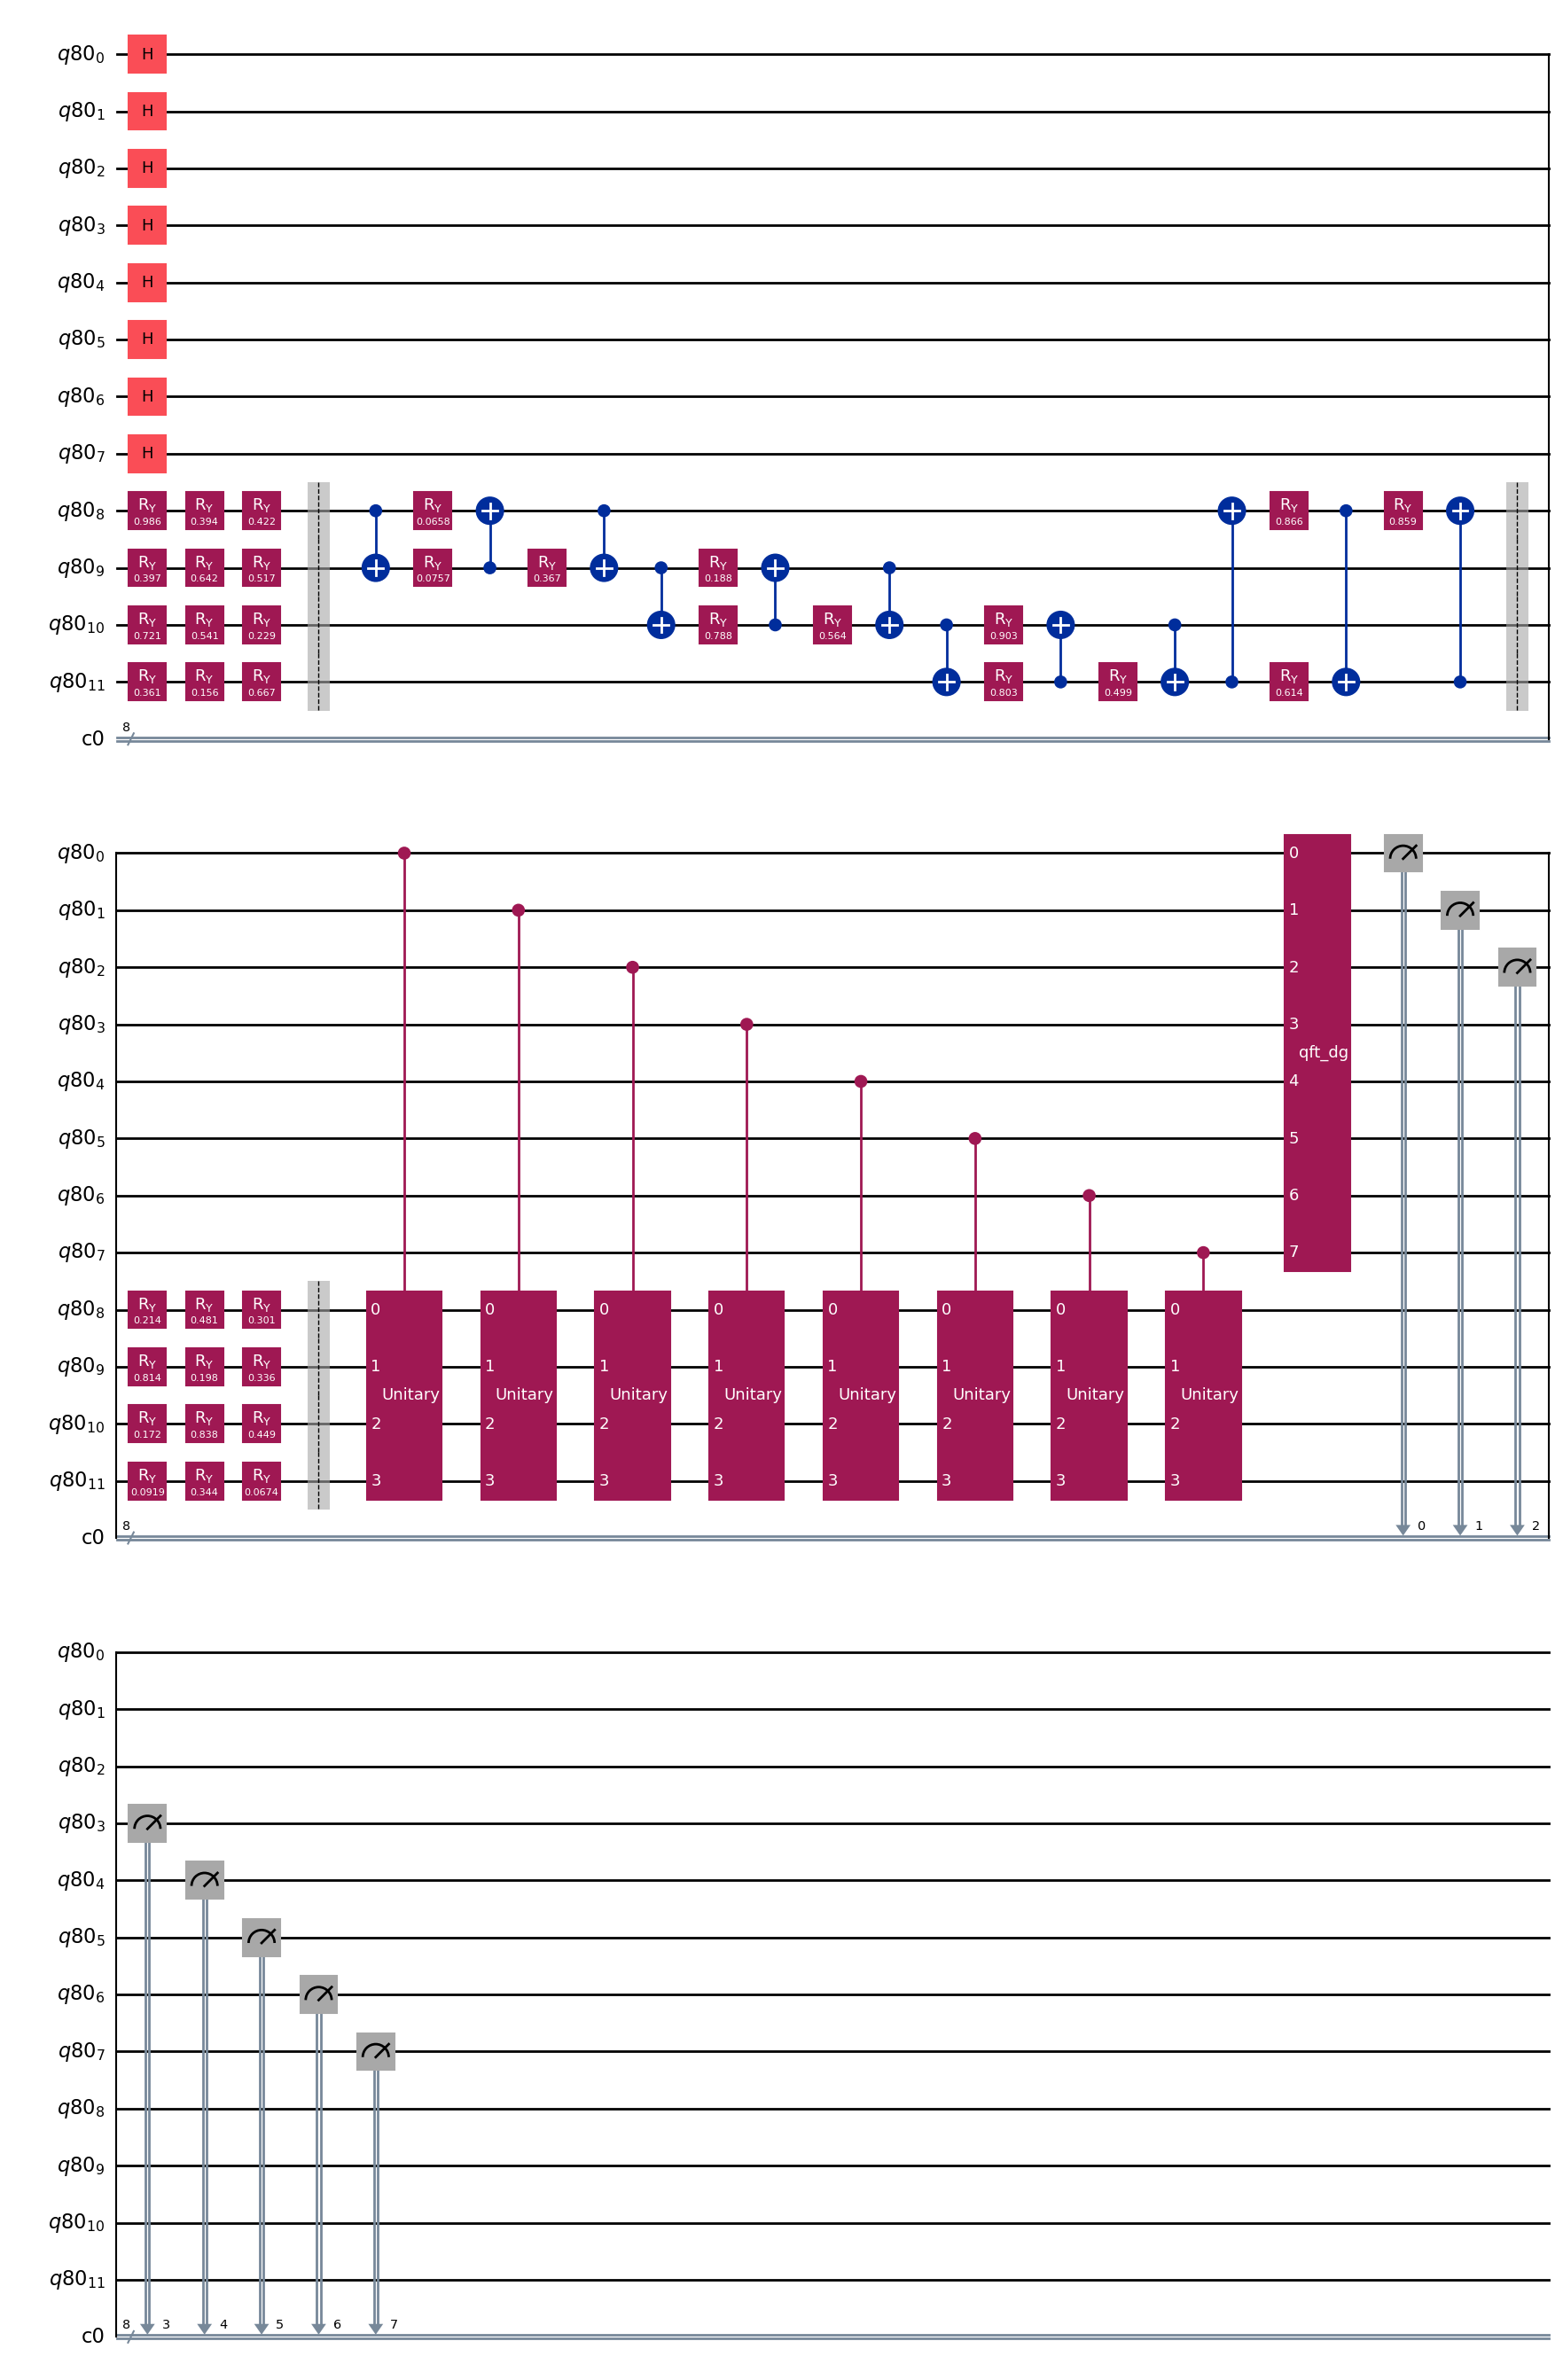

In [11]:
circ(Parameters).draw("mpl") 

In [12]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '00000000'not in result: 
        res = 1
    else:
        res = 1 - result['00000000']/shots
    return res
# cost(parameters)


In [13]:
from qiskit_algorithms.optimizers import GradientDescent

learning_rate = 0.1
def save(nfev,Parameters,cost,stepsize):
    global Cost,Params
    print(nfev,cost)
    Cost.append(cost)
    Params.append(Parameters)
Cost = []
Params = []

optimizer= GradientDescent(maxiter = 2000,learning_rate=learning_rate,tol=1e-4,callback=save)
optimizer.minimize(x0 = Parameters,fun = cost,jac=None)

/tmp/ipykernel_2116395/2620722776.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True,


37 0.83487
74 0.79891
111 0.72195
148 0.6706300000000001
185 0.61191
222 0.56043
259 0.5101100000000001
296 0.4366
333 0.34563
370 0.31222000000000005
407 0.25565000000000004
444 0.23817999999999995
481 0.18723
518 0.17171000000000003
555 0.14495999999999998
592 0.12778
629 0.12089000000000005
666 0.11438999999999999
703 0.11328000000000005
740 0.15952999999999995
777 0.08864000000000005
814 0.09338999999999997
851 0.09179000000000004
888 0.09006000000000003
925 0.11390999999999996
962 0.10928000000000004
999 0.06964999999999999
1036 0.06942999999999999
1073 0.06813999999999998
1110 0.06971000000000005
1147 0.06050999999999995
1184 0.061610000000000054
1221 0.05808000000000002
1258 0.06415000000000004
1295 0.05901999999999996
1332 0.056010000000000004
1369 0.05474000000000001
1406 0.05227999999999999
1443 0.051019999999999954
1480 0.055400000000000005
1517 0.04747000000000001
1554 0.04671000000000003
1591 0.049740000000000006
1628 0.053549999999999986
1665 0.05672999999999995
1702 0.04

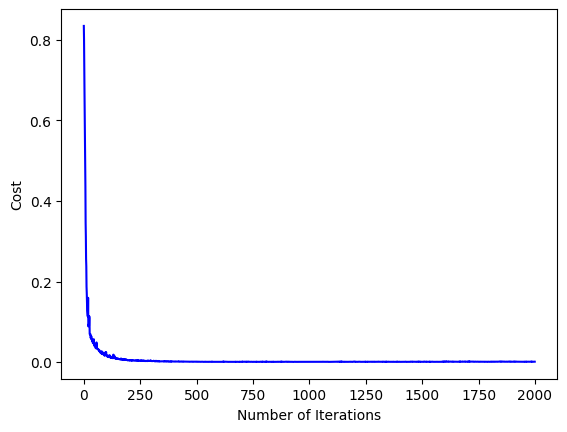

In [14]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [15]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [16]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

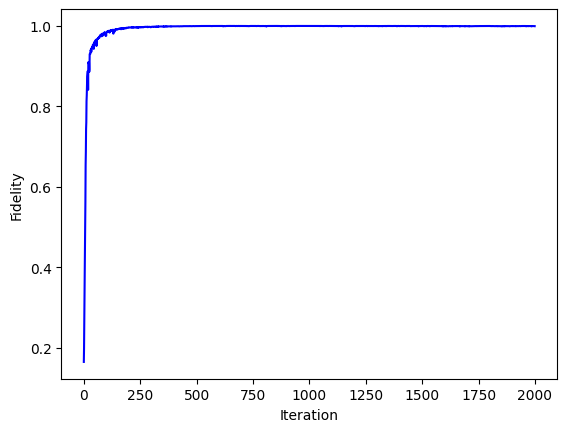

In [17]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [18]:
norm_e[np.argmax(F)]

0.2571817637497592

In [19]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.00232131, 0.02391347, 0.03286346, 0.04306563, 0.05186407,
       0.07586151, 0.09603558, 0.08816569, 0.09227959, 0.09374534,
       0.07881479, 0.07093295, 0.06413356, 0.05290384, 0.03747221,
       0.01807283])

Text(0.5, 0, 'Iteration')

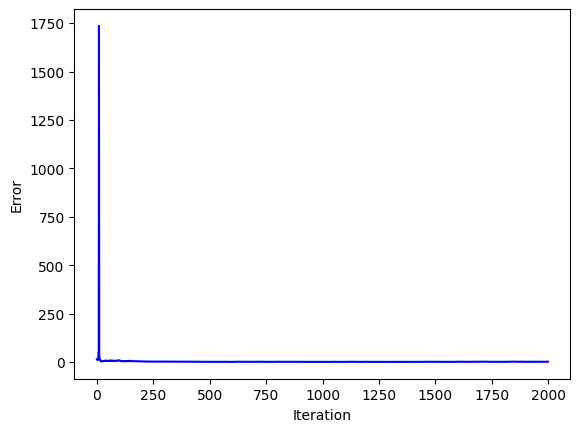

In [20]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [21]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [22]:
abs(np.array(e[-1]))

array([0.01413891, 0.1180355 , 0.18712887, 0.23924643, 0.28717928,
       0.34194841, 0.41106562, 0.38706675, 0.41500534, 0.42713816,
       0.36406396, 0.32997644, 0.29706617, 0.22947701, 0.1752406 ,
       0.0671616 ])

In [23]:
X_opt

array([-0.00648277+0.j, -0.09099402+0.j, -0.15463126+0.j, -0.20556844+0.j,
       -0.24967037+0.j, -0.29199023+0.j, -0.33597222+0.j, -0.33234342+0.j,
       -0.34761169+0.j, -0.35071638+0.j, -0.31442169+0.j, -0.28650101+0.j,
       -0.25420357+0.j, -0.20108911+0.j, -0.14426387+0.j, -0.06275151+0.j])

In [24]:
print(F)

[0.16539089328943019, 0.20029968232356193, 0.2740002999500065, 0.3292262829470949, 0.3862345224250583, 0.439014941969215, 0.4859607283752661, 0.5626057826647215, 0.6541593224556814, 0.6871008819718822, 0.7438445469472389, 0.760247698393621, 0.8128495581675946, 0.8272218067982204, 0.855965874458824, 0.8736880330013912, 0.8798655764355258, 0.8861988410375445, 0.8877712709280212, 0.8408895405375819, 0.9094782062920816, 0.9063227708799291, 0.9078314704108352, 0.908858778611021, 0.8855336721730861, 0.8914656957625231, 0.9297811032150692, 0.9297598750826203, 0.9310786233228684, 0.9302199385929002, 0.9391085502561313, 0.9377421767052156, 0.9427816120630701, 0.9350544784498568, 0.9402554886541339, 0.9446599515012268, 0.944616099955467, 0.9478442653366831, 0.947315844551175, 0.9456473222593926, 0.952363155278968, 0.9535458054828027, 0.9495264373331174, 0.9454726122688297, 0.9426451179080308, 0.9546187157861818, 0.9582908005611706, 0.9551781112837191, 0.9601656111186321, 0.9588501809153243, 0.96

In [25]:
print(norm_e)

[13.666180271973042, 12.018933418228277, 13.386460767777834, 13.837645498615187, 11.830739301631604, 15.281954502462979, 19.745421880751234, 48.9422514461555, 48.37961426166861, 1735.5277513953097, 32.960229724720435, 26.11270668253494, 10.870992482123038, 8.631665256996149, 8.32577889978648, 6.4464974208824275, 7.397352194036434, 7.837079977844913, 5.271160470203518, 3.953679022722442, 4.534550063448625, 3.796719150869711, 3.679680811295326, 3.960890874340681, 3.729314284827661, 3.787946172080639, 4.450516808199194, 4.2661750123516935, 4.84070305787364, 3.984763903387499, 4.780979456623342, 4.765258936941732, 5.084940298985948, 6.395939539763824, 5.68045074623517, 5.284147257420787, 5.294602940125053, 5.6259320320254895, 6.361521872477291, 7.348773225220752, 6.8091194308144765, 5.6183119181522265, 5.255610455826774, 5.09669498390102, 5.627151487753583, 5.4985203792066795, 5.912103039725588, 6.705289022371923, 5.609638669726481, 5.212410189925833, 5.440497601416475, 6.004317008208909, 

In [26]:
min(norm_e)

0.2187390278057615

In [27]:
1-max(F)

0.00041588784016433067